# SHAP values for the sub_model

Warning: This notebook is very computationally intensive

Sources:  
https://shap.readthedocs.io/en/latest/generated/shap.KernelExplainer.html  
https://github.com/shap/shap/blob/master/notebooks/tabular_examples/neural_networks/Census%20income%20classification%20with%20Keras.ipynb

Shap version: shap-0.45.0


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error, r2_score

import keras

import tensorflow as tf


In [32]:
def set_reproducible():
    np.random.seed(12345)
    random.seed(12345)
    tf.random.set_seed(12345)
    
set_reproducible()

In [33]:
dps1200 = pd.read_csv("../../data/dps1200.csv")
dps1200 = dps1200[dps1200["year"] >= 1800]
dpa = pd.read_csv("../../data/dpa.csv")
dpa = dpa[dpa["year"] >= 1800]
daa = pd.read_csv("../../data/daa.csv")
daa = daa[daa["year"] >= 1800]

frames = [dpa, daa, dps1200]

data = pd.concat(frames)

In [34]:
data.rename(columns=lambda x: x.replace('X', '').strip(), inplace=True)
data = data.drop('tree', axis=1)
data = data.drop('type', axis=1)
data = data.drop('origin', axis=1)
data = data.drop('Origin', axis=1)
data = data.drop('Jahr', axis=1)

data.head()

,year,3996,2970,2968,2966,2964,2962,2960,2959,2957,...,818,816,814,812,810,808,806,804,802,800
7,1807,0.012190,0.018461,0.018693,0.018933,0.019180,0.019437,0.019703,0.019981,0.020270,...,-0.021817,-0.021688,-0.021581,-0.021500,-0.021449,-0.021431,-0.021448,-0.021497,-0.021576,-0.021680
27,1808,0.007680,0.017779,0.018064,0.018360,0.018664,0.018977,0.019297,0.019628,0.019973,...,-0.019688,-0.019511,-0.019355,-0.019229,-0.019140,-0.019089,-0.019078,-0.019108,-0.019175,-0.019275
28,1818,0.001696,0.017197,0.017447,0.017709,0.017982,0.018266,0.018564,0.018878,0.019210,...,-0.017498,-0.017263,-0.017062,-0.016904,-0.016795,-0.016738,-0.016734,-0.016778,-0.016866,-0.016991
29,1808,0.003949,0.016106,0.016425,0.016753,0.017091,0.017441,0.017805,0.018182,0.018576,...,-0.017793,-0.017598,-0.017436,-0.017314,-0.017236,-0.017206,-0.017221,-0.017278,-0.017371,-0.017495
30,1817,0.004788,0.017703,0.018036,0.018375,0.018719,0.019069,0.019424,0.019781,0.020142,...,-0.018147,-0.017942,-0.017769,-0.017637,-0.017551,-0.017514,-0.017524,-0.017581,-0.017677,-0.017807


In [35]:
y = data.iloc[:,2:]
feature_labels = y.columns.values
feature_wavelengths = feature_labels.astype(int)

In [36]:
y = data.iloc[:,2:]
xp = y.columns.values
xp = xp.astype(int)

In [37]:
features = data.iloc[:, 2:].values
labels = data.iloc[:, 0].values

In [38]:
train_data, test_data, train_labels, test_labels = train_test_split(features, labels, test_size=0.2, random_state=42)

In [39]:
print(test_data.shape)

(234, 410)


In [40]:
model_path = "1800_sub_model.keras"

In [41]:
dps1200sub_model = tf.keras.models.load_model(model_path)

# Show the model architecture
dps1200sub_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 410, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 205, 64)   │        832 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 205, 64)   │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 205, 64)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 103, 64)   │          0 │ activation[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 103, 32)   │      2,048 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 103, 32)   │        128 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 103, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 103, 32)   │      3,072 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 103, 64)   │     14,336 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 103, 32)   │     11,264 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 103, 128)  │          0 │ conv1d_2[0][0],   │
│ (Concatenate)       │                   │            │ conv1d_3[0][0],   │
│                     │                   │            │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 103, 128)  │     16,384 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 103, 128)  │      8,192 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 103, 128)  │        512 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 103, 128)  │        512 │ conv1d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 103, 128)  │          0 │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 103, 128)  │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 103, 32)   │      4,096 │ activation_2[0][

 Total params: 1,630,021 (6.22 MB)

 Trainable params: 542,401 (2.07 MB)

 Non-trainable params: 2,816 (11.00 KB)

 Optimizer params: 1,084,804 (4.14 MB)

In [42]:
print(type(dps1200sub_model))

<class 'keras.src.models.functional.Functional'>


# SHAP

In [43]:
import shap

In [44]:
def f(X):
    return dps1200sub_model.predict(X, verbose=0).flatten()

In [45]:
# Use the 10-means for representing the dataset
mean_features = shap.kmeans(features, 10)

# Use the kernel exlainer as it's able to exlain an arbitrary function
explainer = shap.KernelExplainer(f, mean_features)

# We need to take more samples than we have features, otherwise we'll get an error
shap_values = explainer.shap_values(features, nsamples=2000)

100%|██████████| 1170/1170 [46:08<00:00,  2.37s/it]


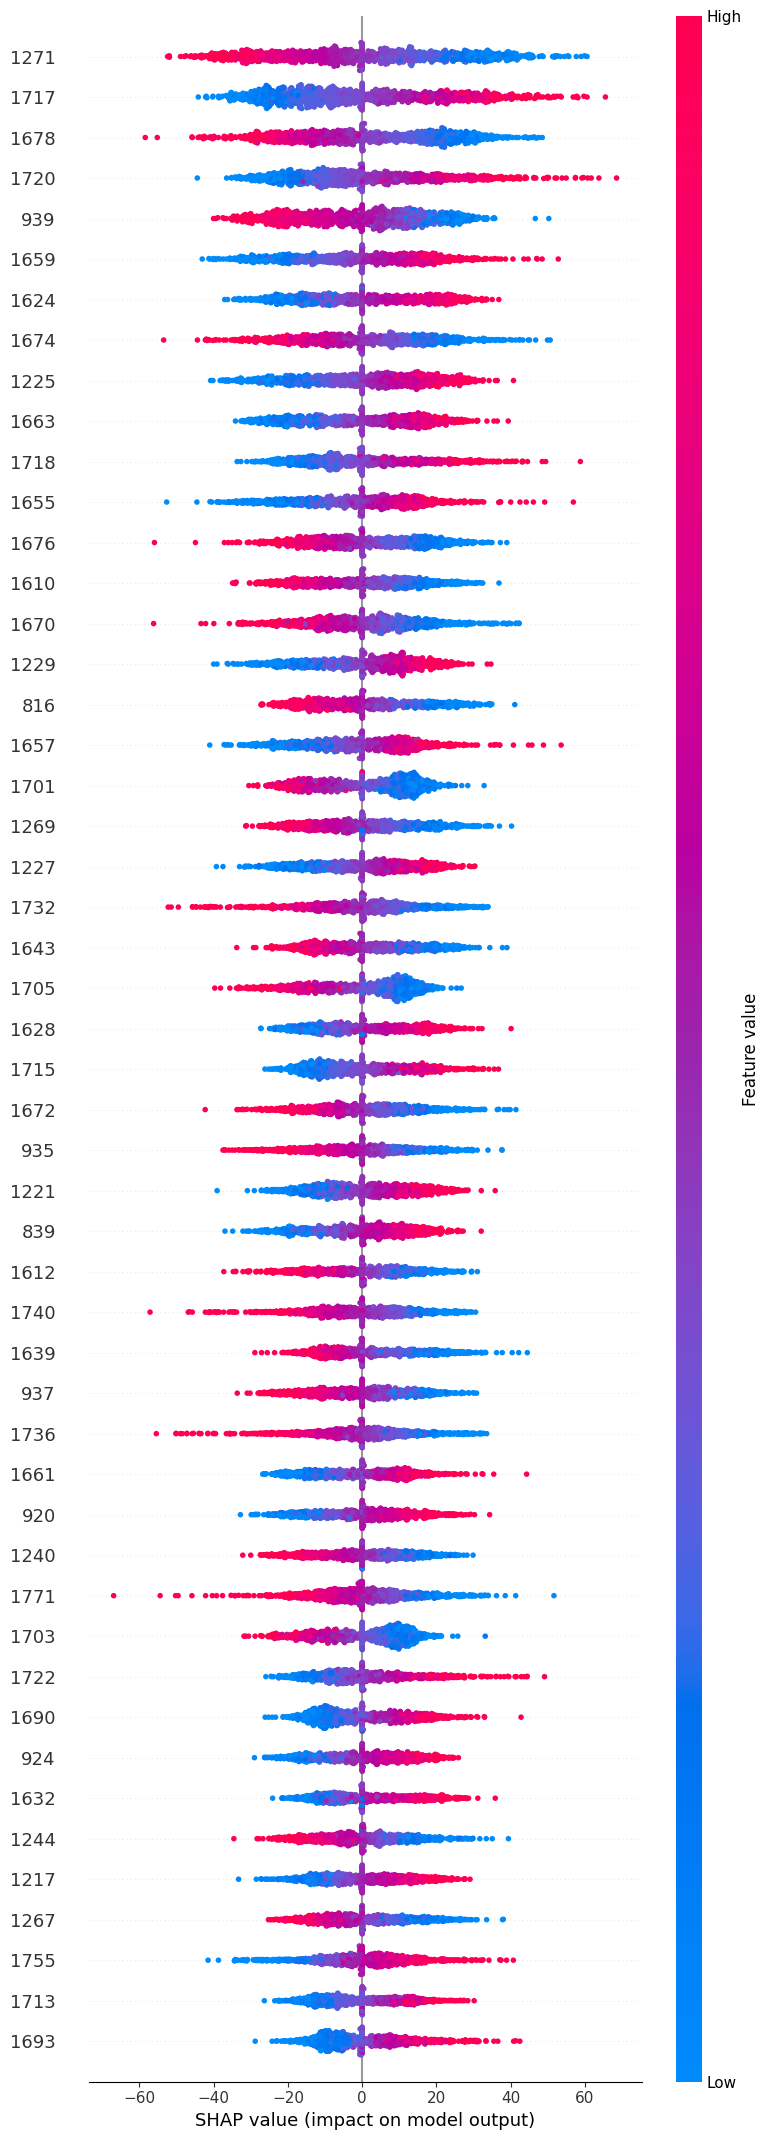

In [46]:
shap.summary_plot(shap_values, features=features, feature_names=feature_labels, max_display=50)

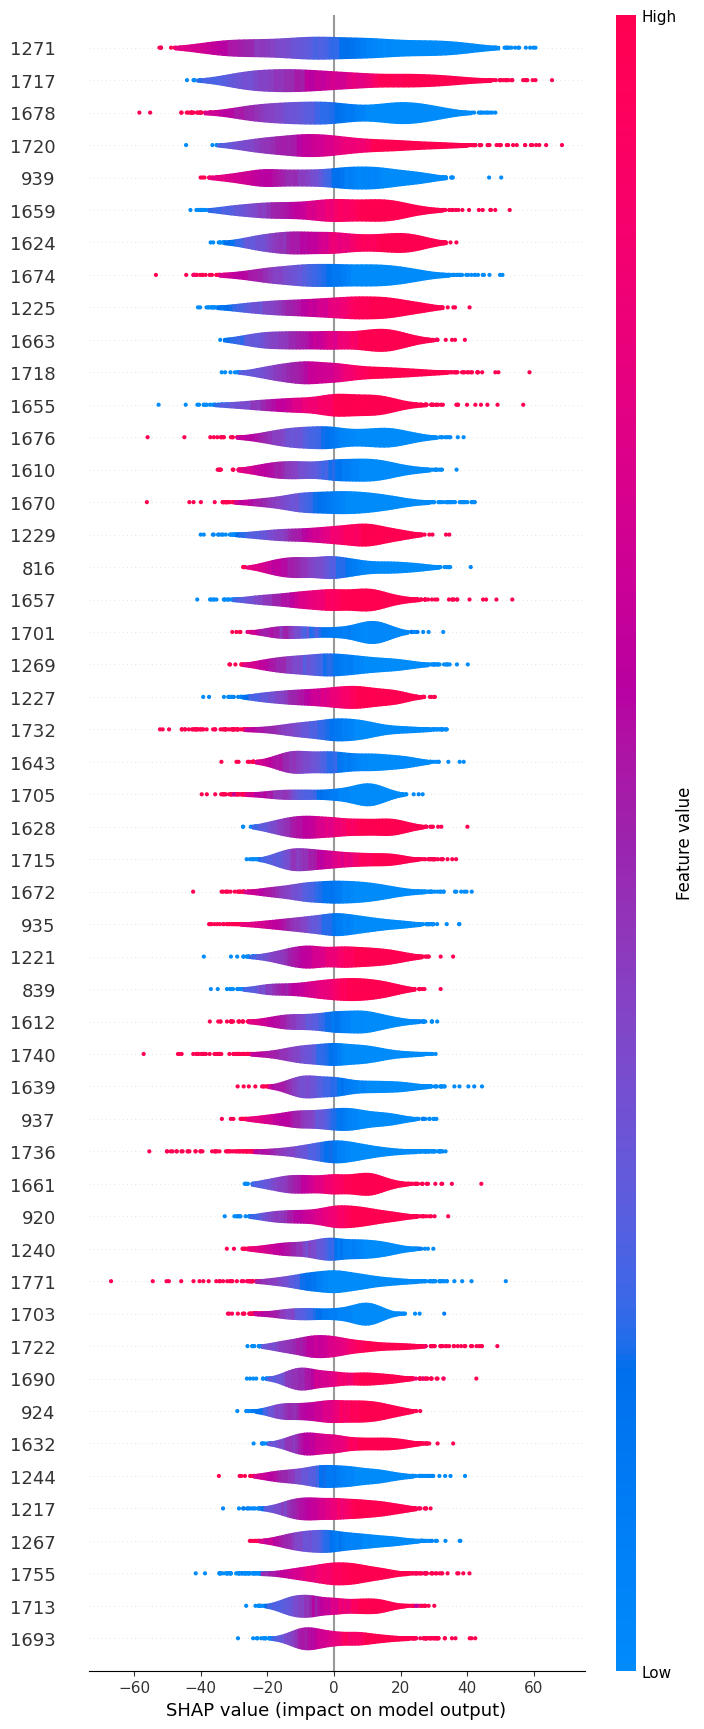

In [47]:
shap.plots.violin(shap_values, features=features, feature_names=feature_labels, max_display=50, plot_type="violin")